Training Accuracy (Random Forest): 0.988
Training Classification Report (Random Forest):
              precision    recall  f1-score   support

           1       0.99      0.99      0.99       185
           2       0.98      0.99      0.99       125
           3       0.94      0.89      0.91        18

    accuracy                           0.99       328
   macro avg       0.97      0.96      0.97       328
weighted avg       0.99      0.99      0.99       328

Training Confusion Matrix (Random Forest):
[[184   1   0]
 [  0 124   1]
 [  1   1  16]]


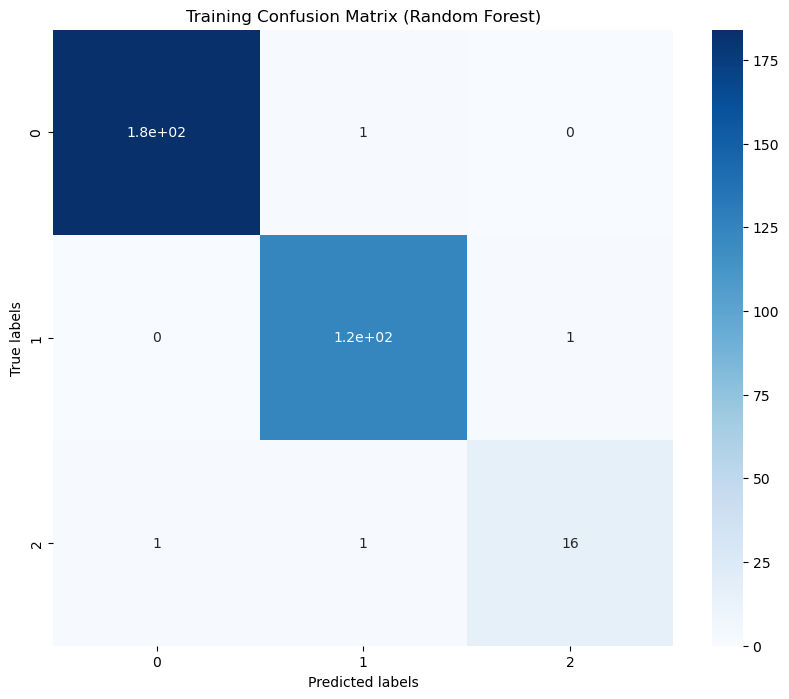

Test Accuracy (Random Forest): 0.759
Test Classification Report (Random Forest):
              precision    recall  f1-score   support

           1       0.89      0.76      0.82        54
           2       0.56      0.79      0.66        24
           3       1.00      0.60      0.75         5

    accuracy                           0.76        83
   macro avg       0.82      0.72      0.74        83
weighted avg       0.80      0.76      0.77        83

Test Confusion Matrix (Random Forest):
[[41 13  0]
 [ 5 19  0]
 [ 0  2  3]]


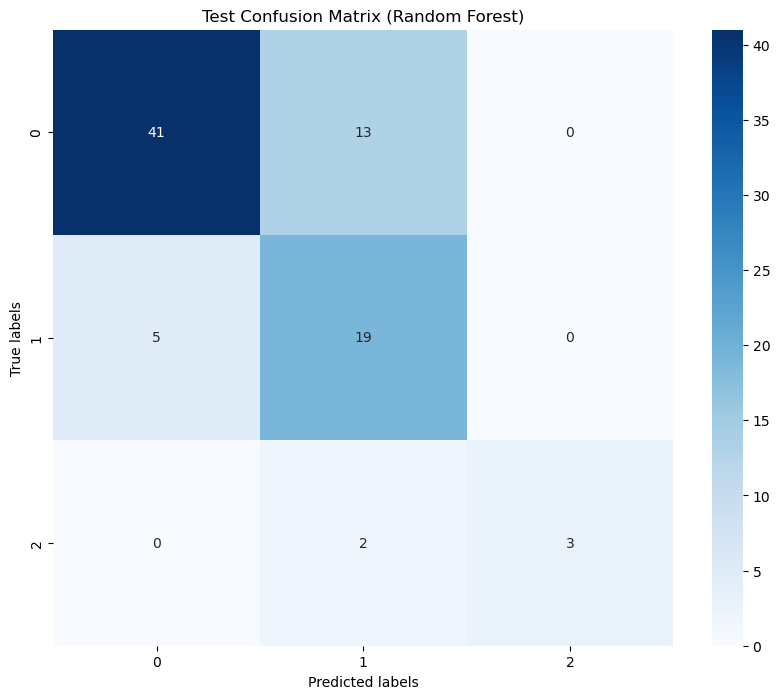

Training Accuracy (Gradient Boosting): 0.988
Training Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

           1       1.00      0.99      0.99       185
           2       0.99      0.98      0.99       125
           3       0.86      1.00      0.92        18

    accuracy                           0.99       328
   macro avg       0.95      0.99      0.97       328
weighted avg       0.99      0.99      0.99       328

Training Confusion Matrix (Gradient Boosting):
[[183   1   1]
 [  0 123   2]
 [  0   0  18]]


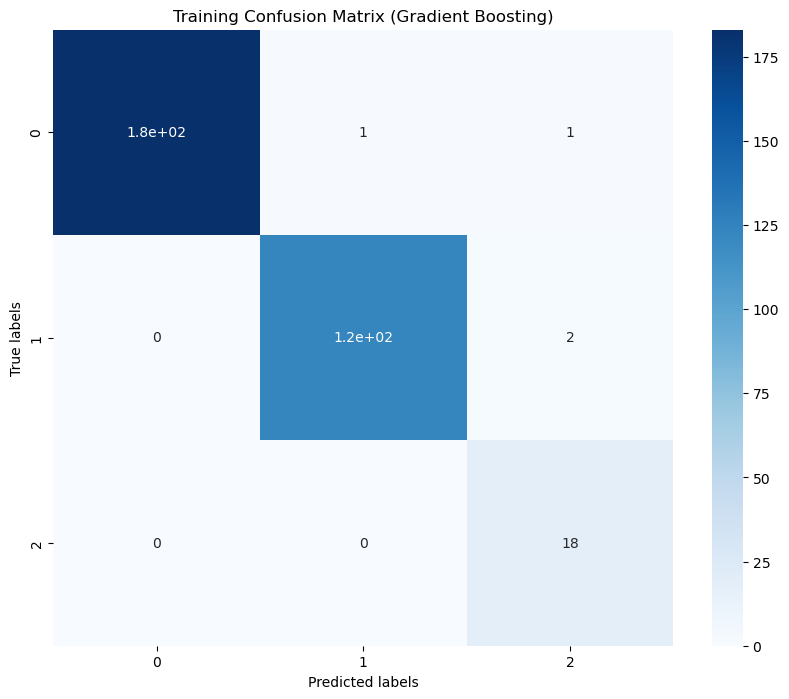

Test Accuracy (Gradient Boosting): 0.783
Test Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

           1       0.91      0.80      0.85        54
           2       0.59      0.79      0.68        24
           3       0.75      0.60      0.67         5

    accuracy                           0.78        83
   macro avg       0.75      0.73      0.73        83
weighted avg       0.81      0.78      0.79        83

Test Confusion Matrix (Gradient Boosting):
[[43 11  0]
 [ 4 19  1]
 [ 0  2  3]]


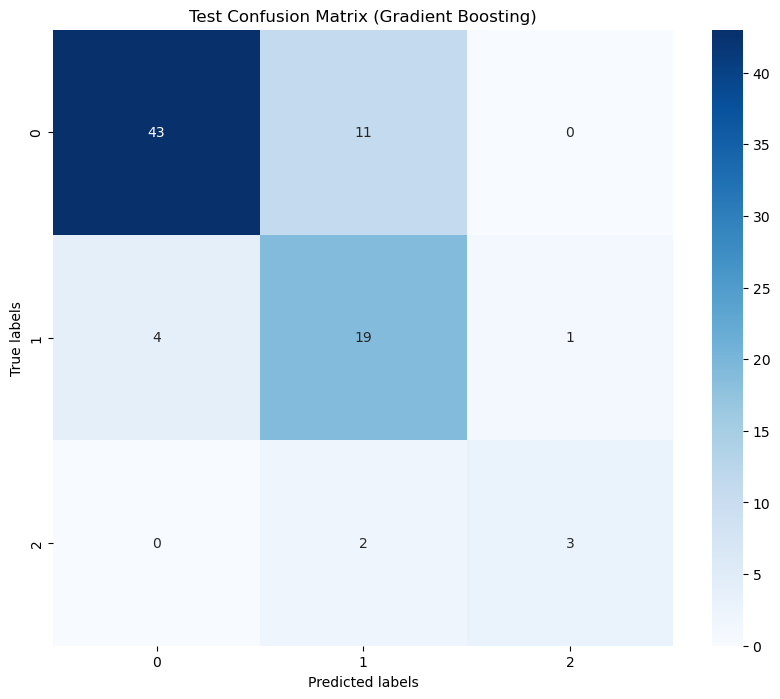

Training Accuracy (SVM): 0.774
Training Classification Report (SVM):
              precision    recall  f1-score   support

           1       0.85      0.84      0.84       185
           2       0.68      0.79      0.73       125
           3       0.00      0.00      0.00        18

    accuracy                           0.77       328
   macro avg       0.51      0.54      0.53       328
weighted avg       0.74      0.77      0.75       328

Training Confusion Matrix (SVM):
[[155  30   0]
 [ 26  99   0]
 [  2  16   0]]


/home/ait/anaconda3/envs/ml-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ait/anaconda3/envs/ml-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ait/anaconda3/envs/ml-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

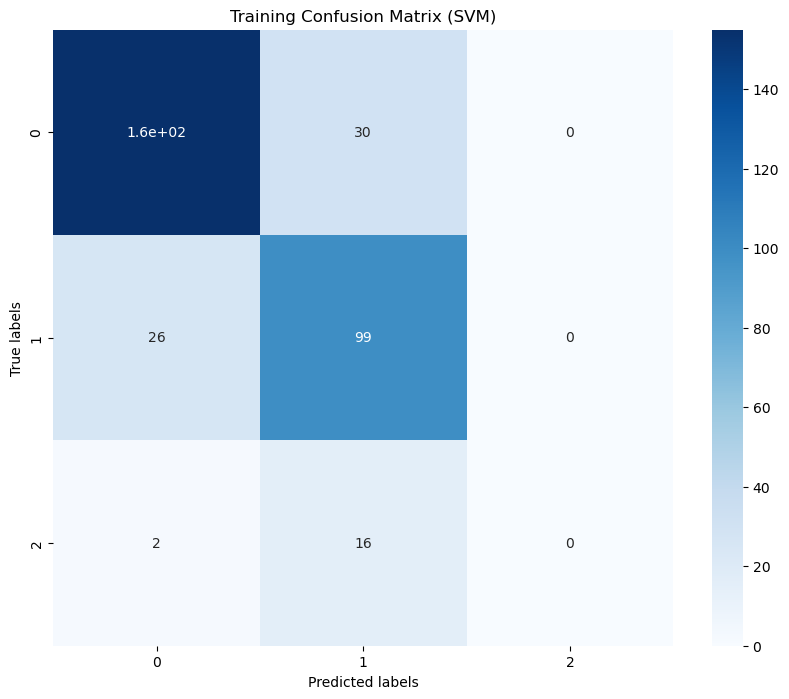

Test Accuracy (SVM): 0.663
Test Classification Report (SVM):
              precision    recall  f1-score   support

           1       0.81      0.70      0.75        54
           2       0.47      0.71      0.57        24
           3       0.00      0.00      0.00         5

    accuracy                           0.66        83
   macro avg       0.43      0.47      0.44        83
weighted avg       0.66      0.66      0.65        83

Test Confusion Matrix (SVM):
[[38 16  0]
 [ 7 17  0]
 [ 2  3  0]]


/home/ait/anaconda3/envs/ml-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ait/anaconda3/envs/ml-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ait/anaconda3/envs/ml-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

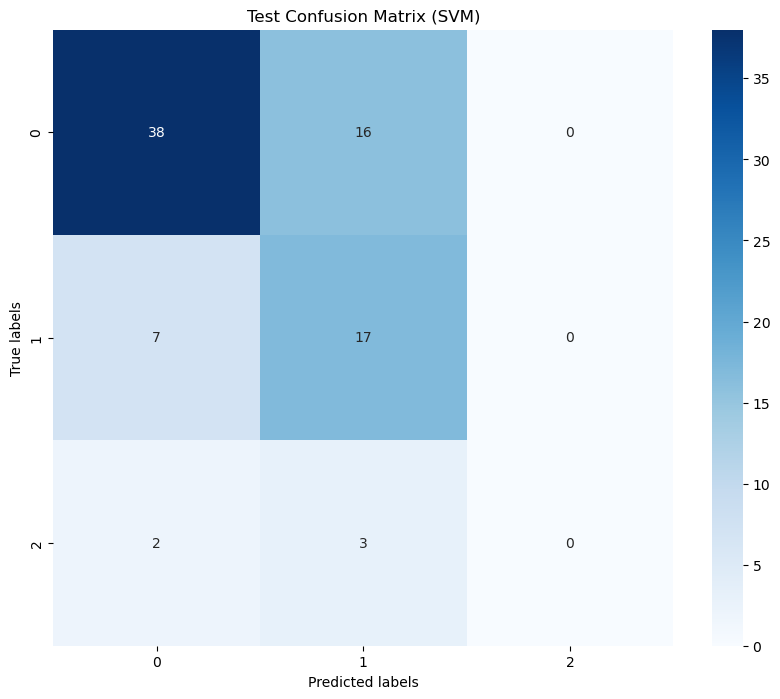

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV data
df1 = pd.read_csv('cleaned_x_data_XRDa_featuresNoise.csv')
df2 = pd.read_csv('y_data_kind.csv')

# Split the data into X (features) and y (target)
X = df1 # features (all columns except 'formula' and 'kind')
y = df2['kind']  # target variable 

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a RandomForestClassifier model
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
rfc.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets
y_train_pred = rfc.predict(X_train_scaled)
y_test_pred = rfc.predict(X_test_scaled)

# Evaluate the model's performance on the training set
accuracy_train = accuracy_score(y_train, y_train_pred)
print(f'Training Accuracy (Random Forest): {accuracy_train:.3f}')

print('Training Classification Report (Random Forest):')
print(classification_report(y_train, y_train_pred))

print('Training Confusion Matrix (Random Forest):')
print(confusion_matrix(y_train, y_train_pred))

# Plot the training confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Training Confusion Matrix (Random Forest)')
plt.show()

# Evaluate the model's performance on the test set
accuracy_test = accuracy_score(y_test, y_test_pred)
print(f'Test Accuracy (Random Forest): {accuracy_test:.3f}')

print('Test Classification Report (Random Forest):')
print(classification_report(y_test, y_test_pred))

print('Test Confusion Matrix (Random Forest):')
print(confusion_matrix(y_test, y_test_pred))

# Plot the test confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Test Confusion Matrix (Random Forest)')
plt.show()

# Train a GradientBoostingClassifier model
gbc = GradientBoostingClassifier(n_estimators=200, random_state=42)
gbc.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets
y_train_pred_gbc = gbc.predict(X_train_scaled)
y_test_pred_gbc = gbc.predict(X_test_scaled)

# Evaluate the model's performance on the training set
accuracy_train_gbc = accuracy_score(y_train, y_train_pred_gbc)
print(f'Training Accuracy (Gradient Boosting): {accuracy_train_gbc:.3f}')

print('Training Classification Report (Gradient Boosting):')
print(classification_report(y_train, y_train_pred_gbc))

print('Training Confusion Matrix (Gradient Boosting):')
print(confusion_matrix(y_train, y_train_pred_gbc))

# Plot the training confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_train, y_train_pred_gbc), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Training Confusion Matrix (Gradient Boosting)')
plt.show()

# Evaluate the model's performance on the test set
accuracy_test_gbc = accuracy_score(y_test, y_test_pred_gbc)
print(f'Test Accuracy (Gradient Boosting): {accuracy_test_gbc:.3f}')

print('Test Classification Report (Gradient Boosting):')
print(classification_report(y_test, y_test_pred_gbc))

print('Test Confusion Matrix (Gradient Boosting):')
print(confusion_matrix(y_test, y_test_pred_gbc))

# Plot the test confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_test_pred_gbc), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Test Confusion Matrix (Gradient Boosting)')
plt.show()

# Train a Support Vector Machines model
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets
y_train_pred_svm = svm.predict(X_train_scaled)
y_test_pred_svm = svm.predict(X_test_scaled)

# Evaluate the model's performance on the training set
accuracy_train_svm = accuracy_score(y_train, y_train_pred_svm)
print(f'Training Accuracy (SVM): {accuracy_train_svm:.3f}')

print('Training Classification Report (SVM):')
print(classification_report(y_train, y_train_pred_svm))

print('Training Confusion Matrix (SVM):')
print(confusion_matrix(y_train, y_train_pred_svm))

# Plot the training confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_train, y_train_pred_svm), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Training Confusion Matrix (SVM)')
plt.show()

# Evaluate the model's performance on the test set
accuracy_test_svm = accuracy_score(y_test, y_test_pred_svm)
print(f'Test Accuracy (SVM): {accuracy_test_svm:.3f}')

print('Test Classification Report (SVM):')
print(classification_report(y_test, y_test_pred_svm))

print('Test Confusion Matrix (SVM):')
print(confusion_matrix(y_test, y_test_pred_svm))

# Plot the test confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_test_pred_svm), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Test Confusion Matrix (SVM)')
plt.show()